Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Visualization style
sns.set_style("whitegrid")

Load DataSet

In [28]:
df = pd.read_csv("../data/ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Name,Category,Quantity,Unit_Price,Discount,Sales,Profit,Region,Payment_Mode
0,ORD0001,2024-01-01 00:00:00.000000,CUST0157,PROD0004,Novel,Books,4,34055,0,136220.0,17218.41,Central,Credit Card
1,ORD0002,2024-01-01 08:46:07.567567,CUST0251,PROD0003,Bottle,Home & Kitchen,1,40690,15,34586.5,4774.40,South,Cash on Delivery
2,ORD0003,2024-01-01 17:32:15.135135,CUST0097,PROD0064,Shoes,Clothing,4,24011,20,76835.2,12008.76,East,Credit Card
3,ORD0004,2024-01-02 02:18:22.702702,CUST0018,PROD0029,Bottle,Home & Kitchen,2,26422,0,52844.0,12431.53,South,UPI
4,ORD0005,2024-01-02 11:04:30.270270,CUST0097,PROD0011,Coffee Maker,Home & Kitchen,2,58293,5,110756.7,12426.56,East,UPI


Dataset overview

In [30]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 13


First 10 records

In [31]:
df.head(10)

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Name,Category,Quantity,Unit_Price,Discount,Sales,Profit,Region,Payment_Mode
0,ORD0001,2024-01-01 00:00:00.000000,CUST0157,PROD0004,Novel,Books,4,34055,0,136220.0,17218.41,Central,Credit Card
1,ORD0002,2024-01-01 08:46:07.567567,CUST0251,PROD0003,Bottle,Home & Kitchen,1,40690,15,34586.5,4774.40,South,Cash on Delivery
2,ORD0003,2024-01-01 17:32:15.135135,CUST0097,PROD0064,Shoes,Clothing,4,24011,20,76835.2,12008.76,East,Credit Card
3,ORD0004,2024-01-02 02:18:22.702702,CUST0018,PROD0029,Bottle,Home & Kitchen,2,26422,0,52844.0,12431.53,South,UPI
4,ORD0005,2024-01-02 11:04:30.270270,CUST0097,PROD0011,Coffee Maker,Home & Kitchen,2,58293,5,110756.7,12426.56,East,UPI
5,ORD0006,2024-01-02 19:50:37.837837,CUST0001,PROD0097,Desk,Furniture,5,9460,20,37840.0,3059.53,West,UPI
6,ORD0007,2024-01-03 04:36:45.405405,CUST0216,PROD0058,Jeans,Clothing,3,27513,20,66031.2,5957.10,Central,Credit Card
7,ORD0008,2024-01-03 13:22:52.972972,CUST0132,PROD0075,T-Shirt,Clothing,5,50552,15,214846.0,50233.20,South,UPI
8,ORD0009,2024-01-03 22:09:00.540540,CUST0260,PROD0027,Shoes,Clothing,4,39720,10,142992.0,27179.60,West,Cash on Delivery
9,ORD0010,2024-01-04 06:55:08.108108,CUST0125,PROD0097,Cookware Set,Home & Kitchen,5,58084,10,261378.0,33042.60,East,Debit Card


Data Information

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      1000 non-null   str    
 1   Order_Date    1000 non-null   str    
 2   Customer_ID   1000 non-null   str    
 3   Product_ID    1000 non-null   str    
 4   Product_Name  1000 non-null   str    
 5   Category      1000 non-null   str    
 6   Quantity      1000 non-null   int64  
 7   Unit_Price    1000 non-null   int64  
 8   Discount      1000 non-null   int64  
 9   Sales         1000 non-null   float64
 10  Profit        1000 non-null   float64
 11  Region        1000 non-null   str    
 12  Payment_Mode  1000 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 101.7 KB


Statistical summary

In [34]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.044000,30018.144000,9.875000,81897.632650,13252.556200
std,1.424814,17111.018549,7.092932,64220.982094,11605.741499
min,1.000000,397.000000,0.000000,337.450000,78.100000
25%,2.000000,14869.750000,5.000000,29702.825000,4449.930000
50%,3.000000,29631.000000,10.000000,61451.350000,9649.725000
75%,4.000000,44848.750000,15.000000,124677.900000,18983.847500
max,5.000000,59964.000000,20.000000,285130.000000,67803.360000


Data cleaning, missing values

In [35]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Customer_ID     0
Product_ID      0
Product_Name    0
Category        0
Quantity        0
Unit_Price      0
Discount        0
Sales           0
Profit          0
Region          0
Payment_Mode    0
dtype: int64

Duplicate records

In [36]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Convert data

In [37]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Order_Date"].dtype

dtype('<M8[us]')

Checking categorical columns

In [38]:
print("Categories:", df["Category"].unique())
print("Regions:", df["Region"].unique())
print("Payment Modes:", df["Payment_Mode"].unique())

Categories: <StringArray>
['Books', 'Home & Kitchen', 'Clothing', 'Furniture', 'Electronics']
Length: 5, dtype: str
Regions: <StringArray>
['Central', 'South', 'East', 'West', 'North']
Length: 5, dtype: str
Payment Modes: <StringArray>
['Credit Card', 'Cash on Delivery', 'UPI', 'Debit Card']
Length: 4, dtype: str


Feature engineering

In [39]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

df[["Sales", "Profit", "Profit_Margin"]].head()

,Sales,Profit,Profit_Margin
0,136220.0,17218.41,12.640148
1,34586.5,4774.40,13.804230
2,76835.2,12008.76,15.629243
3,52844.0,12431.53,23.524960
4,110756.7,12426.56,11.219691


Create month column

In [40]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2024-01-01 00:00:00.000000,2024-01
1,2024-01-01 08:46:07.567567,2024-01
2,2024-01-01 17:32:15.135135,2024-01
3,2024-01-02 02:18:22.702702,2024-01
4,2024-01-02 11:04:30.270270,2024-01


Create year column

In [41]:
df["Year"] = df["Order_Date"].dt.year

df[["Order_Date", "Year"]].head()

,Order_Date,Year
0,2024-01-01 00:00:00.000000,2024
1,2024-01-01 08:46:07.567567,2024
2,2024-01-01 17:32:15.135135,2024
3,2024-01-02 02:18:22.702702,2024
4,2024-01-02 11:04:30.270270,2024


Basic business matrics

In [42]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 81897632.65


Total profits

In [44]:
total_profit = df["Profit"].sum()

print("Total Profit:", round(total_profit, 2))

Total Profit: 13252556.2


Total orders

In [45]:
total_orders = df["Order_ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 1000


Total customers

In [46]:
total_customers = df["Customer_ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 287


Average order value

In [47]:
average_order_value = df["Sales"].sum() / df["Order_ID"].nunique()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 81897.63


Category analysis

In [48]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Books             18439727.65
Home & Kitchen    17002348.50
Electronics       15921679.90
Furniture         15279879.75
Clothing          15253996.85
Name: Sales, dtype: float64

Category wise profit

In [49]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Books             2969684.70
Home & Kitchen    2817195.70
Electronics       2582607.95
Clothing          2563933.12
Furniture         2319134.73
Name: Profit, dtype: float64

Category summary

In [50]:
category_summary = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_summary.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders
Category,,,,
Books,18439727.65,2969684.70,674,206
Home & Kitchen,17002348.50,2817195.70,619,204
Electronics,15921679.90,2582607.95,609,210
Furniture,15279879.75,2319134.73,575,190
Clothing,15253996.85,2563933.12,567,190


Regional analysis

In [51]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
North      17843725.60
South      17265316.75
Central    16021533.35
East       15839441.65
West       14927615.30
Name: Sales, dtype: float64

region wise profit

In [52]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
North      2987575.51
South      2773127.98
Central    2667220.97
East       2480637.79
West       2343993.95
Name: Profit, dtype: float64

Region summary

In [53]:
region_summary = (
    df.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_summary.round(2)

,Total_Sales,Total_Profit,Orders
Region,,,
North,17843725.60,2987575.51,217
South,17265316.75,2773127.98,212
Central,16021533.35,2667220.97,188
East,15839441.65,2480637.79,187
West,14927615.30,2343993.95,196


Monthly sales analysis

In [54]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .sort_index()
)

monthly_sales

Month
2024-01    7092715.60
2024-02    7017361.45
2024-03    7917355.55
2024-04    6422036.00
2024-05    7689600.45
2024-06    7895551.20
2024-07    7031499.60
2024-08    6267584.55
2024-09    6373825.90
2024-10    6194294.45
2024-11    5897370.85
2024-12    6098437.05
Name: Sales, dtype: float64

Monthly profit

In [55]:
monthly_profit = (
    df.groupby("Month")["Profit"]
    .sum()
    .sort_index()
)

monthly_profit

Month
2024-01    1123467.57
2024-02    1113785.99
2024-03    1303275.64
2024-04     978314.45
2024-05    1351309.03
2024-06    1322073.66
2024-07    1104268.62
2024-08    1011516.88
2024-09    1080079.39
2024-10     915686.65
2024-11     930639.00
2024-12    1018139.32
Name: Profit, dtype: float64

Top 10 product by sales

In [56]:
top_products = (
    df.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product_Name
Mouse                4138001.25
Python Book          4123088.50
Business Book        3795261.75
Desk                 3746421.95
Jeans                3654011.40
Data Science Book    3562406.20
SQL Book             3559417.65
Cookware Set         3530657.55
Smartphone           3479487.70
Mixer                3468832.85
Name: Sales, dtype: float64

Top 10 product by profit

In [57]:
top_profit_products = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product_Name
Python Book          673189.96
Smartphone           633205.54
Business Book        628830.99
Jacket               626321.20
Mouse                606546.77
Jeans                596213.44
Bottle               588553.82
Data Science Book    574036.33
Lamp                 569544.53
Mixer                567437.86
Name: Profit, dtype: float64

Top 10 customers by sales

In [58]:
top_customers = (
    df.groupby("Customer_ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer_ID
CUST0108    1068285.70
CUST0074     985250.50
CUST0097     980429.50
CUST0226     902044.70
CUST0189     804805.60
CUST0044     726322.40
CUST0130     713770.95
CUST0154     698525.10
CUST0055     682058.50
CUST0182     679833.95
Name: Sales, dtype: float64

Repeat customers

In [59]:
customer_orders = (
    df.groupby("Customer_ID")["Order_ID"]
    .nunique()
)

repeat_customers = customer_orders[customer_orders > 1]

print("Total Customers:", customer_orders.count())
print("Repeat Customers:", repeat_customers.count())

Total Customers: 287
Repeat Customers: 256


Repeat customers percentage

In [60]:
repeat_customer_percentage = (
    repeat_customers.count() / customer_orders.count()
) * 100

print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Repeat Customer Percentage: 89.2 %


Payment mode analysis

In [61]:
payment_summary = (
    df.groupby("Payment_Mode")
    .agg(
        Total_Orders=("Order_ID", "nunique"),
        Total_Sales=("Sales", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

payment_summary.round(2)

,Total_Orders,Total_Sales
Payment_Mode,,
Credit Card,278,22723545.00
Debit Card,235,20658353.35
Cash on Delivery,235,19767487.55
UPI,252,18748246.75


Monthly sales trend

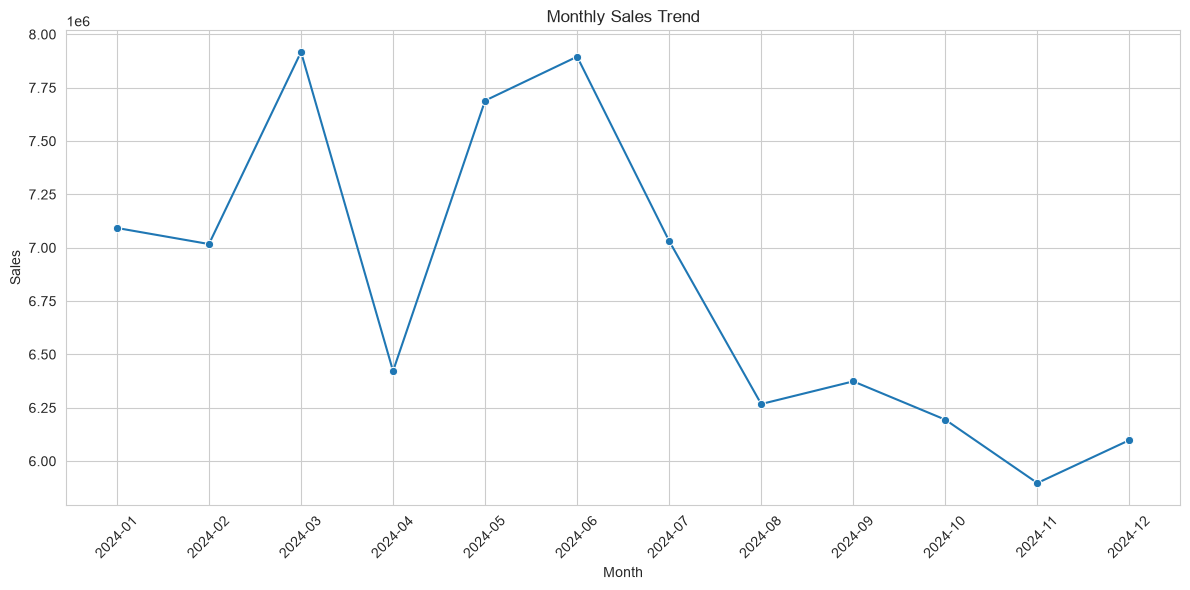

In [71]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualizations/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Category sales

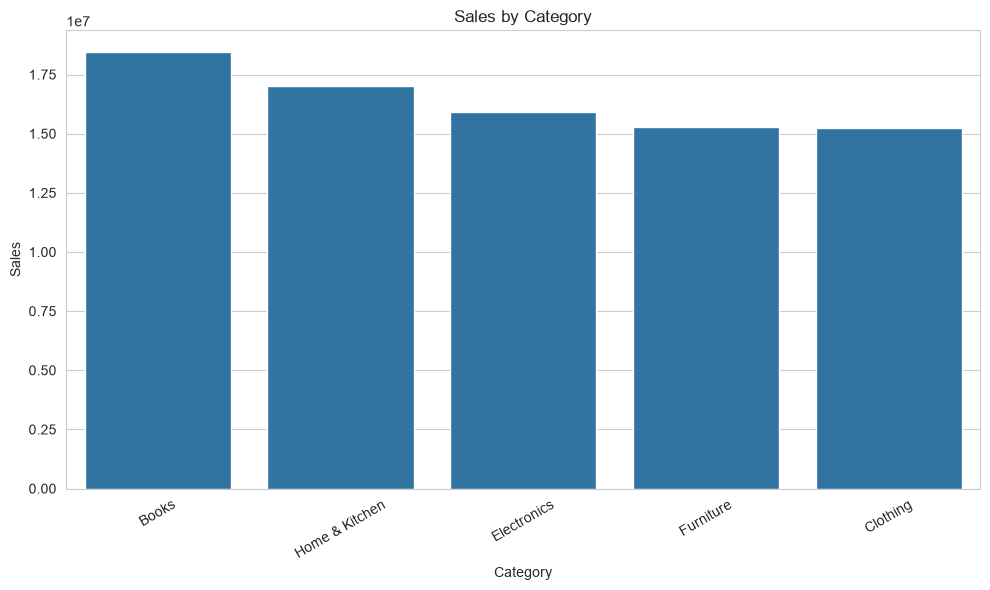

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../visualizations/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Region sales

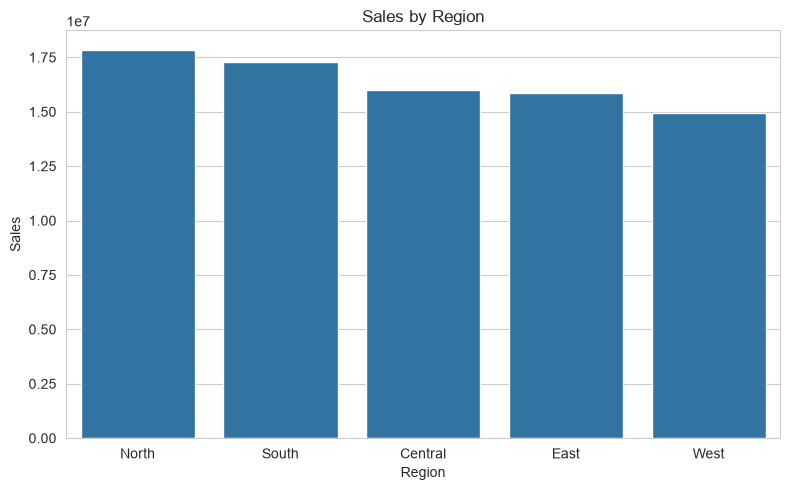

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../visualizations/region_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Top 10 products

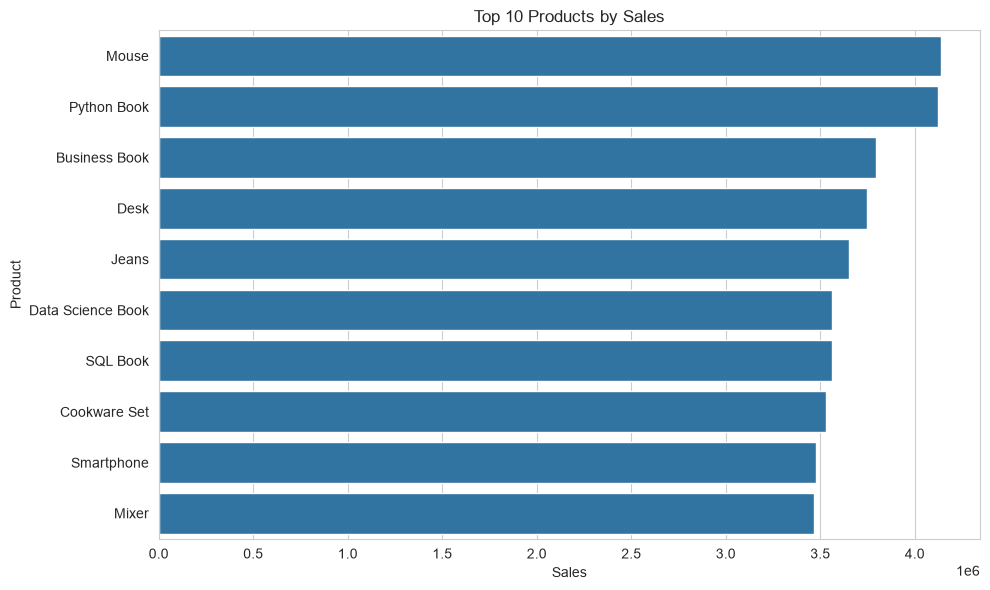

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/top_products.png", dpi=300, bbox_inches="tight")

plt.show()

Payment mode distribution

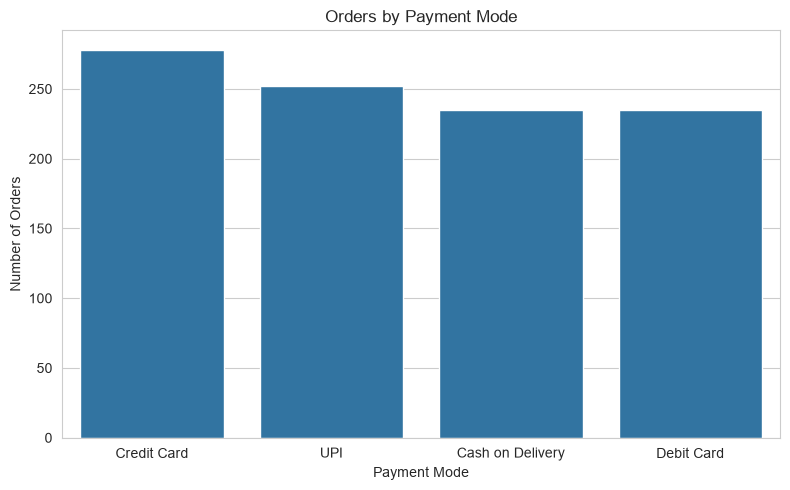

In [75]:
payment_orders = df["Payment_Mode"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_orders.index,
    y=payment_orders.values
)

plt.title("Orders by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("../visualizations/payment_mode.png", dpi=300, bbox_inches="tight")
plt.show()

Sales vs Profit

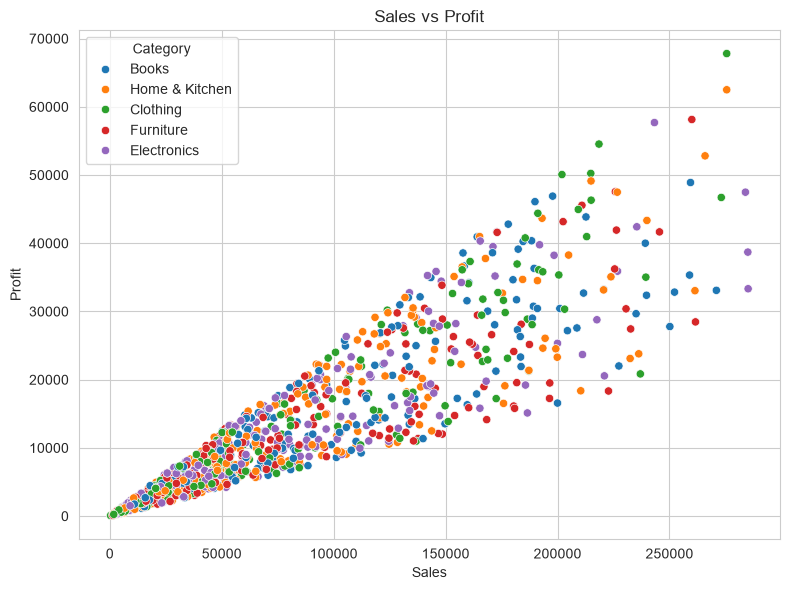

In [76]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("../visualizations/sales_vs_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation analysis

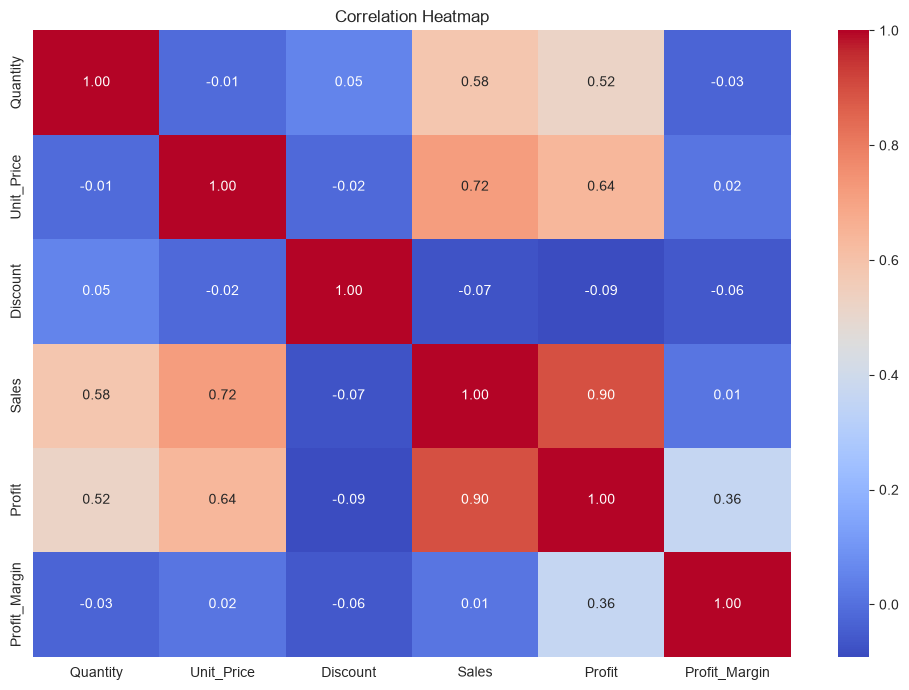

In [77]:
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit",
    "Profit_Margin"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The analysis provides insights into sales performance, customer behavior,
product performance, regional performance, and payment preferences.